# Импорты

In [21]:
# system & utilities
import os
import gzip
import time
import pickle
import pytz
import warnings
warnings.filterwarnings('ignore')

# data analysis and wrangling

import math
import numpy as np
import pandas as pd
import datetime as dt
import random as rnd
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from typing import Dict, List, Optional
from scipy import stats
from scipy.stats import skew, norm

# database & integrations
from clickhouse_driver import Client
import gspread
from gspread_dataframe import set_with_dataframe
from oauth2client.service_account import ServiceAccountCredentials
from google.oauth2.service_account import Credentials

# reporting & notifications
from slack_sdk import WebClient
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font
from openpyxl.utils import get_column_letter

# visualization & display
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from itables import init_notebook_mode, show

# notebook settings
%matplotlib inline
init_notebook_mode(all_interactive=True)
pd.set_option('display.float_format', '{:.2f}'.format)

# machine learning
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, QuantileTransformer

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, KFold

from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

from sklearn.metrics import (
    log_loss,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,

    average_precision_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    mean_squared_error, 
    root_mean_squared_error
)





engine = Client(host='data-dep.owdp.tech',
                user='artem_aksenov',
                password='Nb+SESHO/m1FFr5',
                secure=True,
    )

# EDA

In [ ]:
train = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

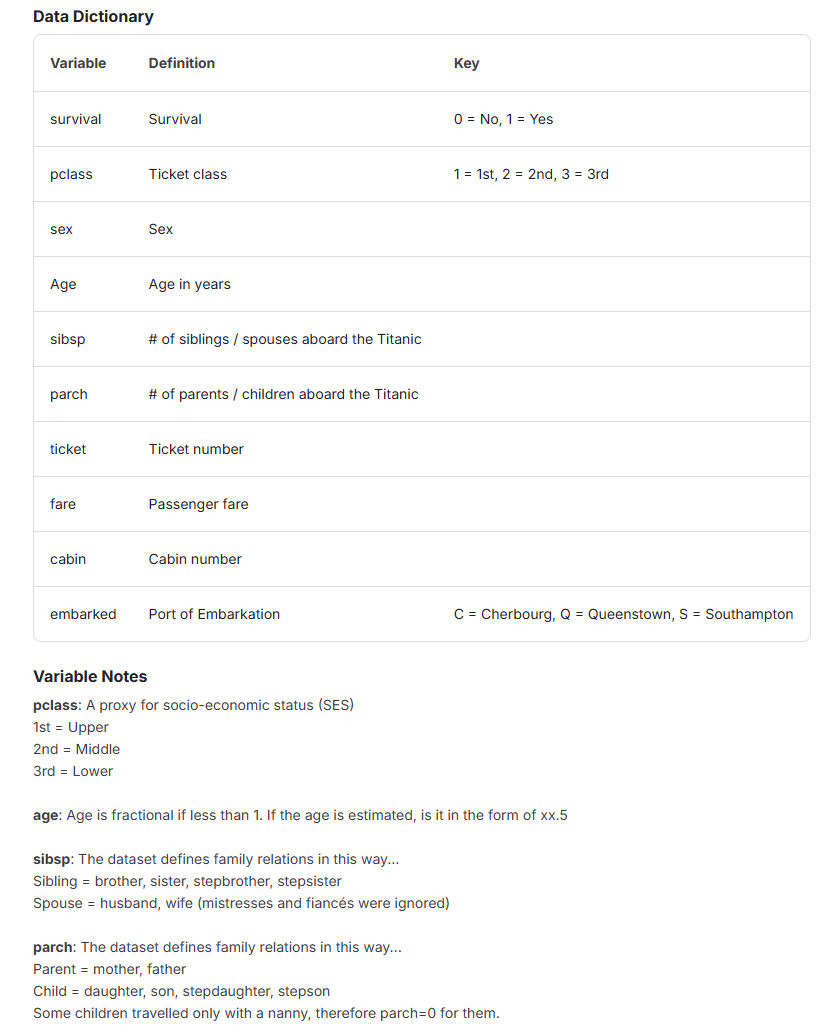

In [ ]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
train.describe(include = "all").T

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [ ]:
missing_count = train.isna().sum()
print(missing_count)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

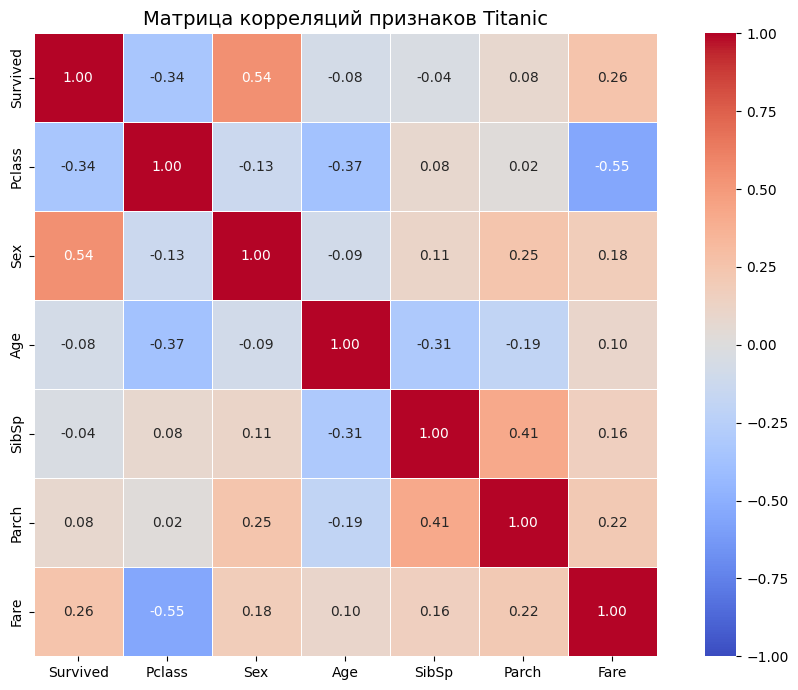

In [ ]:
# Кодируем пол в числовой вид (female = 1, male = 0) для корреляции
df_corr = train.copy()
df_corr['Sex'] = df_corr['Sex'].map({'female': 1, 'male': 0})

# Выбираем только числовые колонки
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df_corr[numeric_cols].corr()

# Построение тепловой карты
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
)

plt.title('Матрица корреляций признаков Titanic', fontsize=14)
plt.tight_layout()
plt.show()

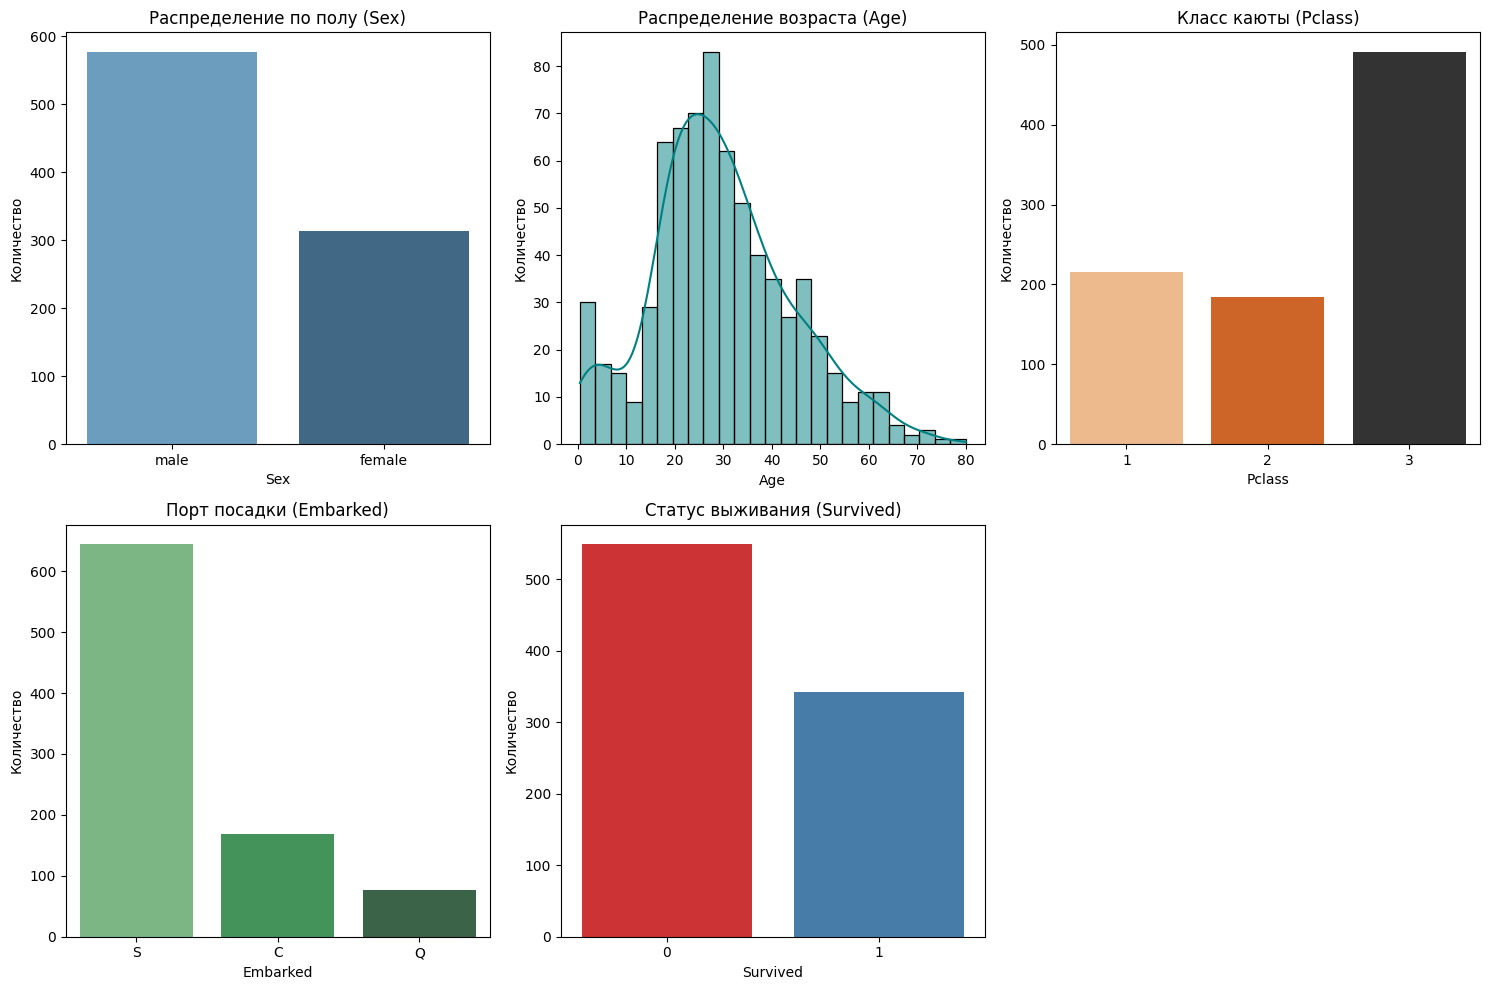

In [ ]:
cols = ['Sex', 'Age', 'Pclass', 'Embarked', 'Survived']

# Визуализация распределений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Sex
sns.countplot(data=train, x='Sex', ax=axes[0], hue='Sex', legend=False, palette='Blues_d')
axes[0].set_title('Распределение по полу (Sex)')
axes[0].set_ylabel('Количество')

# Age (непрерывная переменная — гистограмма с KDE)
sns.histplot(data=train, x='Age', kde=True, bins=25, ax=axes[1], color='teal')
axes[1].set_title('Распределение возраста (Age)')
axes[1].set_ylabel('Количество')

# Pclass
sns.countplot(data=train, x='Pclass', ax=axes[2], hue='Pclass', legend=False, palette='Oranges_d')
axes[2].set_title('Класс каюты (Pclass)')
axes[2].set_ylabel('Количество')

# Embarked
sns.countplot(data=train, x='Embarked', ax=axes[3], hue='Embarked', legend=False, palette='Greens_d')
axes[3].set_title('Порт посадки (Embarked)')
axes[3].set_ylabel('Количество')

# Survived
sns.countplot(data=train, x='Survived', ax=axes[4], hue='Survived', legend=False, palette='Set1')
axes[4].set_title('Статус выживания (Survived)')
axes[4].set_ylabel('Количество')

# Удаление неиспользуемого 6-го графика
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

1) По матрице корреляций видно, что на выживаемость в первую очередь влияет пол и класс билета
2) По классу: на него влияет возраст и плата за билет, причем обратно пропорционально, ну потому что 1 класс стоит дороже, а третий дешевле, то есть корреляция обратная
3) По возрасту: есть корреляция, чем выше возраст тем больше членов семьи на борту
4) По статусу: Pclass коррелирует с Fare, поэтому плату за билет лучше удалить, чтобы не было мультиколлениарности 

In [ ]:
survived = train.groupby(['Sex', 'Pclass'], as_index=False).agg(

    survived_count=('Survived', 'sum'),
    total_count=('Survived', 'count'),

    ).sort_values(['Sex', 'Pclass'], ascending=[True, True])

survived['chance_sur'] = round(survived['survived_count'] / survived['total_count'], 2)

survived

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Женщин выжило больше, чем мужчин

In [ ]:
survived = train.groupby(['Sex', 'Embarked'], as_index=False).agg(

    survived_count=('Survived', 'sum'),
    total_count=('Survived', 'count'),

    ).sort_values(['Sex', 'Embarked'], ascending=[True, True])

survived['chance_sur'] = round(survived['survived_count'] / survived['total_count'], 2)

survived

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


Видим что мужчин и женщин из порта C выжило больше

Вывод:

Выкинуть столбцы: 
1) Ticket (потому что практически уникальные значения), 
2) Cabin (много пропусков, НО возможно если дополнительно их заполнить реальной инфой, то это местоположение может дать доп очки), 
3) Fare (цена билет по сути отображена в колонке Pclass, опять же потенциально можно преобразовать в доп переменную либо понадеятся что этот столбец дополнительно потом еще даст большее значение метрики)
4) Name (логически это вообще ни на что влиять не может, но опять же как доп фича преобразованная может дать еще прирост метрики)

Преобразовать: Parch, SibSp (логика в том, что как будто если у людей больше детей/родственников, то они могли забить место в шлюпке)

Оставить: 
1) Sex (тут сильная корреляция, по статистике женщин выжило больше), 
2) Pclass (по статистике выжило больше пассажиров 1 и 2 класса), 
3) Age (возможно если преобразовать в категориальный признак, то окажется что выжившие мужчины - дети/подростки), 
4) Embarked (по статистике частично повлияло на выживаемость)


# Обработка + создание доп фичей

In [13]:
train = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test  = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

In [ ]:
train.drop(columns=['Survived'])
train['Survived']

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


v1

# Baseline

In [ ]:
# 1. Загрузка исходных сырых данных
train_df = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test_df  = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

# Разделяем признаки и таргет в обучающей выборке
X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

# 2. Определение колонок для обработки
num_cols = ['Age', 'Parch', 'SibSp']
cat_cols = ['Pclass', 'Sex', 'Embarked']

# 3. Создаем обработчик данных (Preprocess Pipeline)
numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median'))]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
    ]
)

# 4. Функция оценки моделей через Кросс-Валидацию
def evaluate_baseline_models(X, y, models_dict, score_name='Score_v1', cv_splits=5):
    results = {}
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    for name, model in models_dict.items():
        # Склеиваем обработку и модель в единый цельный Pipeline
        full_pipeline = Pipeline(
            steps=[('preprocessor', preprocessor), ('model', model)]
        )

        # Кросс-валидация: медиана считается заново для каждого фолда автоматически!
        scores = cross_val_score(
            full_pipeline, X, y, cv=skf, scoring='roc_auc', n_jobs=-1
        )
        results[name] = round(scores.mean(), 4)

    return (
        pd.DataFrame(list(results.items()), columns=['Model', score_name])
        .sort_values(by=score_name, ascending=False)
        .reset_index(drop=True)
    )

# 5. Запуск оценки моделей
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
}

results_df = evaluate_baseline_models(X, y, models, score_name='Score_v1')
print(results_df)

                Model  Score_v1
0            CatBoost      0.86
1  LogisticRegression      0.85


In [9]:
from preprocessing import process_and_align_datasets, process_and_align_datasets_v2, process_and_align_datasets_v3, process_and_align_datasets_v4, evaluate_baseline_models

# 1. Обработка данных:
X_train, Y_train, X_test = process_and_align_datasets(train, test)
# Оценка моделей на подготовленных данных
sorted_model1 = evaluate_baseline_models(X_train, Y_train, X_test, score_name='Score_v1')

# 2.Обработка данных:
X_train, Y_train, X_test = process_and_align_datasets_v2(train, test)
# Оценка моделей на подготовленных данных
sorted_model2 = evaluate_baseline_models(X_train, Y_train, X_test, score_name='Score_v2')

# 3. Обработка данных:
X_train, Y_train, X_test = process_and_align_datasets_v3(train, test)
# Оценка моделей на подготовленных данных
sorted_model3 = evaluate_baseline_models(X_train, Y_train, X_test, score_name='Score_v3')

# 4. Обработка данных:
X_train, Y_train, X_test = process_and_align_datasets_v4(train, test)
# Оценка моделей на подготовленных данных
sorted_model4 = evaluate_baseline_models(X_train, Y_train, X_test, score_name='Score_v4')

dfs = [sorted_model1, sorted_model2, sorted_model3, sorted_model4]

# Последовательно джойним все датафреймы по ключевой колонке 'Model'
final_scores = reduce(
    lambda left, right: pd.merge(left, right, on='Model', how='outer'), dfs
)

# Опционально: сортируем по последнему скору (например, 'Score_v4')
final_scores = final_scores.sort_values(by='Score_v4', ascending=False).reset_index(drop=True)
final_scores

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


# Модели

в1

In [11]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

X_train, Y_train, X_test = process_and_align_datasets(train, test)

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="accuracy",
    run_mode="tune",
    tuning_config=tuning_cfg,
    score_name="Score_v1",
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores_v1 = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
# sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 0.1276967449445099}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 146, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 0.5475310529007109, 'bootstrap': False}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 177, 'learning_rate': 0.06815965954473854, 'num_leaves': 61, 'max_depth': 5, 'subsample': 0.7877560730258549, 'colsample_bytree': 0.7342946917331382, 'reg_alpha': 0.95268811740296, 'reg_lambda': 3.9326753388853484, 'min_child_samples': 25}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 265, 'learning_rate': 0.076597641641058, 'max_depth': 9, 'subsample': 0.8628766303550209, 'colsample_bytree': 0.7916527811562954, 'gamma': 0.10833719588739116, 'reg_alpha': 1.0371372642177452, 'reg_lambda': 6.1359485220897

в2

In [208]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

X_train, Y_train, X_test = process_and_align_datasets_v2(train, test)

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="accuracy",
    run_mode="tune",
    tuning_config=tuning_cfg,
    score_name="Score_v2",
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores_v2 = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
# sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 0.23020620776471645}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 92, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 0.5081308124610617, 'bootstrap': True}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 210, 'learning_rate': 0.07464246271670746, 'num_leaves': 19, 'max_depth': 3, 'subsample': 0.6019210372656457, 'colsample_bytree': 0.6007418075266603, 'reg_alpha': 0.009867457884349395, 'reg_lambda': 8.686075293235998, 'min_child_samples': 39}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 128, 'learning_rate': 0.06163695566941518, 'max_depth': 6, 'subsample': 0.8514873711845425, 'colsample_bytree': 0.9881227990235864, 'gamma': 0.6000860593683064, 'reg_alpha': 0.18489822795541366, 'reg_lambda': 4.83697644

в3

In [226]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

X_train, X_test = process_and_align_datasets_v3(train, test)
Y_train = train["Survived"]

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="accuracy",
    run_mode="tune",
    tuning_config=tuning_cfg,
    score_name="Score_v3",
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores_v3 = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
# sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 0.7908105572433127}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 135, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 0.5436846212066332, 'bootstrap': False}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 273, 'learning_rate': 0.06107403172837388, 'num_leaves': 43, 'max_depth': 4, 'subsample': 0.969621951981553, 'colsample_bytree': 0.9444372622431765, 'reg_alpha': 2.051069405803034, 'reg_lambda': 1.8794886603743737, 'min_child_samples': 51}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 214, 'learning_rate': 0.029816529763242096, 'max_depth': 6, 'subsample': 0.9699243167348163, 'colsample_bytree': 0.7117178673653813, 'gamma': 0.6759455378187692, 'reg_alpha': 1.215774774577472, 'reg_lambda': 1.2498068984704

в4

In [249]:
from ml_pipeline import TuningConfig, PipelineConfig, MLPipeline

X_train, Y_train, X_test = process_and_align_datasets_v4(train, test)

# 1. Настройка тюнинга Optuna для всех 5 моделей классификации
tuning_cfg = TuningConfig(
    search_engine="optuna",
    n_trials=30,  # Можно увеличить (например, до 20-30) для более точного поиска
    param_spaces={

        "lgb": {
            
        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "num_leaves": (15, 63),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_samples": (10, 100),

        }, "xgb": {

        "n_estimators": (50, 300),
        "learning_rate": (0.001, 0.1),
        "max_depth": (3, 10),
        "subsample": (0.6, 1.0),
        "colsample_bytree": (0.6, 1.0),
        "gamma": (1e-8, 1.0),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0),
        "min_child_weight": (1, 10),

        }, "cat": {

        "iterations": (100, 400),
        "learning_rate": (0.001, 0.1),
        "depth": (4, 8),
        "l2_leaf_reg": (1.0, 10.0),
        "subsample": (0.6, 1.0),
        "random_strength": (1e-3, 10.0),

        }, "rf": {

        "n_estimators": (50, 200),
        "max_depth": (3, 12),
        "min_samples_split": (2, 20),
        "min_samples_leaf": (1, 10),
        "max_features": (0.5, 1.0),
        "bootstrap": [True, False],

        }, "logreg": {

        "C": (0.001, 10.0),
        }
    }
)

# 2. Главная конфигурация — добавляем все модели в active_models
config = PipelineConfig(
    task="binary",
    val_strategy="stratified",
    n_splits=5,
    metric="accuracy",
    run_mode="tune",
    tuning_config=tuning_cfg,
    score_name="Score_v4",
    active_models=["logreg", "rf", "lgb", "xgb", "cat"]
)

# 3. Инициализация пайплайна
pipeline = MLPipeline(config=config)

# 4. Обучение и поиск гиперпараметров
scores_v4 = pipeline.fit(X=X_train, y=Y_train)

# 5. Инференс на тестовой выборке
sub_preds = pipeline.predict(X_test=X_test)

# Вывод результатов (в ensemble_pred теперь усреднение всех 5 моделей)
# sub_preds.head()

[Tuner] Старт подбора для 'logreg' (30 итераций)...
[Tuner] Лучшие параметры для logreg: {'C': 1.1033845084491696}
[Tuner] Старт подбора для 'rf' (30 итераций)...
[Tuner] Лучшие параметры для rf: {'n_estimators': 71, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.6574501329852016, 'bootstrap': False}
[Tuner] Старт подбора для 'lgb' (30 итераций)...
[Tuner] Лучшие параметры для lgb: {'n_estimators': 122, 'learning_rate': 0.059260553166661144, 'num_leaves': 36, 'max_depth': 9, 'subsample': 0.8204654129180536, 'colsample_bytree': 0.7212836399694379, 'reg_alpha': 0.6577658149753874, 'reg_lambda': 0.9887721627732526, 'min_child_samples': 25}
[Tuner] Старт подбора для 'xgb' (30 итераций)...
[Tuner] Лучшие параметры для xgb: {'n_estimators': 145, 'learning_rate': 0.07837896078569961, 'max_depth': 6, 'subsample': 0.8727324272528594, 'colsample_bytree': 0.9440996120479944, 'gamma': 0.9141199910284594, 'reg_alpha': 0.8367910846222637, 'reg_lambda': 8.77838376946

Финал

In [250]:
final_scores

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [252]:
dfs = [scores_v1, scores_v2, scores_v3, scores_v4]

# Последовательно джойним все датафреймы по ключевой колонке 'Model'
final_scores2 = reduce(
    lambda left, right: pd.merge(left, right, on='Model', how='outer'), dfs
)

# Опционально: сортируем по последнему скору (например, 'Score_v3')
final_scores2 = final_scores2.sort_values(by='Score_v3', ascending=False).reset_index(drop=True)
final_scores2

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [253]:
sub_preds

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [258]:
# 1. Загружаем исходный тестовый файл или файл примера сабмита, чтобы взять PassengerId
test_df = pd.read_csv(r"C:\jupyter\kaggle\titanik\gender_submission.csv")

# 2. Переводим вероятности ансамбля в бинарный класс (0 или 1) с порогом 0.5
# Выбираем столбцы: ensemble_pred, cat_pred или lgb_pred
final_predictions = (sub_preds['lgb_pred'] >= 0.5).astype(int)

# 3. Формируем итоговый датафрейм для Kaggle
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': final_predictions
})

# 4. Сохраняем в CSV без индексов
submission.to_csv('submission_lgb_pred_v4.csv', index=False)

print("Файл submission_lgb_pred_v4.csv успешно создан!")
print(submission.head())

Файл submission_lgb_pred_v4.csv успешно создан!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


v5

In [245]:
def prepare_titanic_data(train_df, test_df):
    # Копируем датасеты, чтобы не менять исходные
    df_train = train_df.copy()
    df_test = test_df.copy()
    
    # 1. Заполнение Fare в test медианой из train (без утечки данных)
    fare_median = df_train['Fare'].median()
    df_train['Fare'] = df_train['Fare'].fillna(fare_median)
    df_test['Fare'] = df_test['Fare'].fillna(fare_median)
    
    # 2. Заполнение Age медианой по группам (Sex, Pclass) из train
    age_medians = df_train.groupby(['Sex', 'Pclass'])['Age'].median()
    
    def fill_age(df):
        return df.apply(
            lambda row: age_medians.loc[(row['Sex'], row['Pclass'])] if pd.isna(row['Age']) else row['Age'], 
            axis=1
        ).astype(int)
        
    df_train['Age'] = fill_age(df_train)
    df_test['Age'] = fill_age(df_test)
    
    # 3. Маппинг категорий (Sex и Embarked)
    sex_map = {'male': 0, 'female': 1}
    embarked_map = {'S': 0, 'C': 1, 'Q': 2}
    
    for df in [df_train, df_test]:
        df['Sex'] = df['Sex'].map(sex_map)
        df['Embarked'] = df['Embarked'].fillna('S').map(embarked_map)
        
        # 4. Признаки семьи
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
        
    # Выделяем нужные колонки признаков
    feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
    
    X_train = df_train[feature_cols]
    Y_train = df_train['Survived']
    X_test = df_test[feature_cols]
    
    return X_train, Y_train, X_test

# Применяем к твоим исходным датасетам
X_train, Y_train, X_test = prepare_titanic_data(train, test)

In [ ]:
# 1. Список из 10 разных конфигураций и типов моделей
configs_list = [
    ("lgb", {"n_estimators": 150, "learning_rate": 0.03, "num_leaves": 31, "max_depth": 5, "subsample": 0.8}),
    ("lgb", {"n_estimators": 250, "learning_rate": 0.01, "num_leaves": 15, "max_depth": 4, "reg_alpha": 1.0}),
    ("lgb", {"n_estimators": 100, "learning_rate": 0.05, "num_leaves": 63, "max_depth": 7, "reg_lambda": 5.0}),
    ("lgb", {"n_estimators": 200, "learning_rate": 0.02, "num_leaves": 20, "subsample": 0.7}),
    ("xgb", {"n_estimators": 150, "learning_rate": 0.03, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8}),
    ("xgb", {"n_estimators": 200, "learning_rate": 0.015, "max_depth": 6, "gamma": 0.1, "reg_alpha": 0.5}),
    ("xgb", {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.6}),
    ("cat", {"iterations": 250, "learning_rate": 0.03, "depth": 5, "l2_leaf_reg": 3.0}),
    ("cat", {"iterations": 350, "learning_rate": 0.015, "depth": 4, "l2_leaf_reg": 5.0}),
    ("cat", {"iterations": 150, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 1.0}),
]

test_predictions = []
scores_list = []

# 2. Обучаем каждую из 10 моделей через PipelineConfig
for idx, (model_type, params) in enumerate(configs_list, 1):
    cfg = PipelineConfig(
        task="binary",
        val_strategy="stratified",
        n_splits=5,
        metric="accuracy",
        run_mode="train_only",
        score_name=f"Score_m{idx}",
        active_models=[model_type],
        models_params={model_type: params},
        random_state=42 + idx  # Разный seed для разнообразия
    )
    
    pipe = MLPipeline(config=cfg)
    score_df = pipe.fit(X=X_train, y=Y_train)
    
    # Сохраняем предсказания на тесте
    preds = pipe.predict(X_test=X_test)
    test_predictions.append(preds[f"{model_type}_pred"].values)
    
    acc = score_df.iloc[0][f"Score_m{idx}"]
    scores_list.append({"Model": f"{model_type}_{idx}", "Accuracy": acc})

# 3. Усредняем предсказания всех 10 моделей (Ensemble)
ensemble_probs = np.mean(test_predictions, axis=0)

# 4. Формируем submission.csv
sub = pd.read_csv(r"C:\jupyter\kaggle\titanik\gender_submission.csv")
sub["Survived"] = (ensemble_probs >= 0.5).astype(int)
sub.to_csv("submission_10_boosters.csv", index=False)

print("\n--- Результаты 10 моделей ---")
print(pd.DataFrame(scores_list))
print("\nУспешно сохранен submission_10_boosters.csv!")


=================== Training: lgb ===================
--> Total OOF ACCURACY: 0.8316

=================== Training: lgb ===================
--> Total OOF ACCURACY: 0.8215

=================== Training: lgb ===================
--> Total OOF ACCURACY: 0.8260

=================== Training: lgb ===================
--> Total OOF ACCURACY: 0.8373

=================== Training: xgb ===================
--> Total OOF ACCURACY: 0.8249

=================== Training: xgb ===================
--> Total OOF ACCURACY: 0.8249

=================== Training: xgb ===================
--> Total OOF ACCURACY: 0.8260

=================== Training: cat ===================
--> Total OOF ACCURACY: 0.8283

=================== Training: cat ===================
--> Total OOF ACCURACY: 0.8148

=================== Training: cat ===================
--> Total OOF ACCURACY: 0.8126

--- Результаты 10 моделей ---
    Model  Accuracy
0   lgb_1     83.16
1   lgb_2     82.15
2   lgb_3     82.60
3   lgb_4     83.73
4   xgb_5

# DL

### v1

In [304]:
X_train, Y_train, X_test = process_and_align_datasets(train, test)

from dl_pipeline import DLConfig, DLTrainer

# Преобразуем данные в numpy массивы, если они переданы как pandas DataFrame/Series
X_tr = X_train.values if hasattr(X_train, 'values') else X_train
Y_tr = Y_train.values if hasattr(Y_train, 'values') else Y_train    

# 1. Конфигурация простой архитектуры: 2 линейных слоя + ReLU
cfg_simple = DLConfig(
    hidden_units=[64, 32],       # Двухслойный MLP
    activation='relu',           # Активация
    use_batchnorm=False,         # Без BatchNorm
    dropout_rates=0.0,           # Без Dropout
    optimizer_name='adam',       # Простой Adam
    lr=1e-3,
    batch_size=64,
    epochs=15,
    use_scheduler=False,         # Без планировщика LR
    task='binary'
)

# 2. Обучение модели
trainer_simple = DLTrainer(cfg_simple)
history_simple = trainer_simple.fit(X_tr, Y_tr)

# 3. Инференс и расчет метрик качество на тесте
train_probs = trainer_simple.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/15 | Train Loss: 0.7106 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6609 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6611 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.6576 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.6551 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.6442 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.6367 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.6241 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.6104 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.5960 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.5862 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.5671 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.5540 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.5533 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.5224 | LR: 0.001000

--- Метрики качества (Simple MLP - Train) ---
Train Accuracy: 0.7901
Train ROC-AUC:  0.8475


In [294]:
# Настраиваем глубокую сеть с регуляризацией и сchedulers
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],       # Больше слоев разной ширины
    activation='gelu',                     # Попробуем GELU (или leaky_relu, elu, silu)
    use_batchnorm=True,                    # Добавляем BatchNorm
    dropout_rates=[0.3, 0.3, 0.2, 0.1],    # Dropout под каждый скрытый слой
    optimizer_name='adamw',                # AdamW с весовым затуханием
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,                        # Увеличили размер батча
    epochs=25,
    use_scheduler=True,                    # Косинусовый scheduler
    scheduler_type='cosine',
    task='binary'
)

# Запуск обучения
trainer_adv = DLTrainer(cfg_advanced)
history_adv = trainer_adv.fit(X_tr, Y_tr)

# Предсказание вероятностей и расчет метрики (например, Accuracy или ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

train_probs = trainer_adv.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/25 | Train Loss: 0.6634 | LR: 0.001992
Epoch 02/25 | Train Loss: 0.6295 | LR: 0.001969
Epoch 03/25 | Train Loss: 0.5790 | LR: 0.001930
Epoch 04/25 | Train Loss: 0.5317 | LR: 0.001876
Epoch 05/25 | Train Loss: 0.4919 | LR: 0.001809
Epoch 06/25 | Train Loss: 0.4747 | LR: 0.001729
Epoch 07/25 | Train Loss: 0.4539 | LR: 0.001637
Epoch 08/25 | Train Loss: 0.4479 | LR: 0.001536
Epoch 09/25 | Train Loss: 0.4447 | LR: 0.001426
Epoch 10/25 | Train Loss: 0.4437 | LR: 0.001309
Epoch 11/25 | Train Loss: 0.4399 | LR: 0.001187
Epoch 12/25 | Train Loss: 0.4283 | LR: 0.001063
Epoch 13/25 | Train Loss: 0.4314 | LR: 0.000937
Epoch 14/25 | Train Loss: 0.4316 | LR: 0.000813
Epoch 15/25 | Train Loss: 0.4229 | LR: 0.000691
Epoch 16/25 | Train Loss: 0.4070 | LR: 0.000574
Epoch 17/25 | Train Loss: 0.4114 | LR: 0.000464
Epoch 18/25 | Train Loss: 0.4208 | LR: 0.000363
Epoch 19/25 | Train Loss: 0.4067 | LR: 0.000271
Epoch 20/25 | Train Loss: 0.4042 | LR: 0.000191
Epoch 21/25 | Train Loss: 0.4105 | LR: 0

### v2

In [295]:
X_train, Y_train, X_test = process_and_align_datasets_v2(train, test)

from dl_pipeline import DLConfig, DLTrainer

# Преобразуем данные в numpy массивы, если они переданы как pandas DataFrame/Series
X_tr = X_train.values if hasattr(X_train, 'values') else X_train
Y_tr = Y_train.values if hasattr(Y_train, 'values') else Y_train    

# 1. Конфигурация простой архитектуры: 2 линейных слоя + ReLU
cfg_simple = DLConfig(
    hidden_units=[64, 32],       # Двухслойный MLP
    activation='relu',           # Активация
    use_batchnorm=False,         # Без BatchNorm
    dropout_rates=0.0,           # Без Dropout
    optimizer_name='adam',       # Простой Adam
    lr=1e-3,
    batch_size=64,
    epochs=15,
    use_scheduler=False,         # Без планировщика LR
    task='binary'
)

# 2. Обучение модели
trainer_simple = DLTrainer(cfg_simple)
history_simple = trainer_simple.fit(X_tr, Y_tr)

# 3. Инференс и расчет метрик качество на тесте
train_probs = trainer_simple.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/15 | Train Loss: 0.6729 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6394 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6126 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.5841 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.5550 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.5247 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.4983 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.4761 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.4646 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.4580 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.4499 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.4460 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.4439 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.4427 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.4402 | LR: 0.001000

--- Метрики качества (Simple MLP - Train) ---
Train Accuracy: 0.8047
Train ROC-AUC:  0.8631


In [296]:
# Настраиваем глубокую сеть с регуляризацией и сchedulers
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],       # Больше слоев разной ширины
    activation='gelu',                     # Попробуем GELU (или leaky_relu, elu, silu)
    use_batchnorm=True,                    # Добавляем BatchNorm
    dropout_rates=[0.3, 0.3, 0.2, 0.1],    # Dropout под каждый скрытый слой
    optimizer_name='adamw',                # AdamW с весовым затуханием
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,                        # Увеличили размер батча
    epochs=25,
    use_scheduler=True,                    # Косинусовый scheduler
    scheduler_type='cosine',
    task='binary'
)

# Запуск обучения
trainer_adv = DLTrainer(cfg_advanced)
history_adv = trainer_adv.fit(X_tr, Y_tr)

# Предсказание вероятностей и расчет метрики (например, Accuracy или ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

train_probs = trainer_adv.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/25 | Train Loss: 0.6295 | LR: 0.001992
Epoch 02/25 | Train Loss: 0.5203 | LR: 0.001969
Epoch 03/25 | Train Loss: 0.4777 | LR: 0.001930
Epoch 04/25 | Train Loss: 0.4486 | LR: 0.001876
Epoch 05/25 | Train Loss: 0.4411 | LR: 0.001809
Epoch 06/25 | Train Loss: 0.4277 | LR: 0.001729
Epoch 07/25 | Train Loss: 0.4272 | LR: 0.001637
Epoch 08/25 | Train Loss: 0.4200 | LR: 0.001536
Epoch 09/25 | Train Loss: 0.4213 | LR: 0.001426
Epoch 10/25 | Train Loss: 0.4128 | LR: 0.001309
Epoch 11/25 | Train Loss: 0.4125 | LR: 0.001187
Epoch 12/25 | Train Loss: 0.4221 | LR: 0.001063
Epoch 13/25 | Train Loss: 0.4191 | LR: 0.000937
Epoch 14/25 | Train Loss: 0.4168 | LR: 0.000813
Epoch 15/25 | Train Loss: 0.4063 | LR: 0.000691
Epoch 16/25 | Train Loss: 0.4104 | LR: 0.000574
Epoch 17/25 | Train Loss: 0.4188 | LR: 0.000464
Epoch 18/25 | Train Loss: 0.4111 | LR: 0.000363
Epoch 19/25 | Train Loss: 0.4156 | LR: 0.000271
Epoch 20/25 | Train Loss: 0.4166 | LR: 0.000191
Epoch 21/25 | Train Loss: 0.4105 | LR: 0

### v3

In [302]:
X_train, Y_train, X_test = process_and_align_datasets_v3(train, test)

from dl_pipeline import DLConfig, DLTrainer

# Преобразуем данные в numpy массивы, если они переданы как pandas DataFrame/Series
X_tr = X_train.values if hasattr(X_train, 'values') else X_train
Y_tr = Y_train.values if hasattr(Y_train, 'values') else Y_train    

# 1. Конфигурация простой архитектуры: 2 линейных слоя + ReLU
cfg_simple = DLConfig(
    hidden_units=[64, 32],       # Двухслойный MLP
    activation='relu',           # Активация
    use_batchnorm=False,         # Без BatchNorm
    dropout_rates=0.0,           # Без Dropout
    optimizer_name='adam',       # Простой Adam
    lr=1e-3,
    batch_size=64,
    epochs=15,
    use_scheduler=False,         # Без планировщика LR
    task='binary'
)

# 2. Обучение модели
trainer_simple = DLTrainer(cfg_simple)
history_simple = trainer_simple.fit(X_tr, Y_tr)

# 3. Инференс и расчет метрик качество на тесте
train_probs = trainer_simple.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/15 | Train Loss: 0.6801 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6467 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6213 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.5910 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.5529 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.5072 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.4725 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.4495 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.4370 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.4351 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.4290 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.4252 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.4233 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.4251 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.4209 | LR: 0.001000

--- Метрики качества (Simple MLP - Train) ---
Train Accuracy: 0.8193
Train ROC-AUC:  0.8703


In [298]:
# Настраиваем глубокую сеть с регуляризацией и сchedulers
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],       # Больше слоев разной ширины
    activation='gelu',                     # Попробуем GELU (или leaky_relu, elu, silu)
    use_batchnorm=True,                    # Добавляем BatchNorm
    dropout_rates=[0.3, 0.3, 0.2, 0.1],    # Dropout под каждый скрытый слой
    optimizer_name='adamw',                # AdamW с весовым затуханием
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,                        # Увеличили размер батча
    epochs=25,
    use_scheduler=True,                    # Косинусовый scheduler
    scheduler_type='cosine',
    task='binary'
)

# Запуск обучения
trainer_adv = DLTrainer(cfg_advanced)
history_adv = trainer_adv.fit(X_tr, Y_tr)

# Предсказание вероятностей и расчет метрики (например, Accuracy или ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

train_probs = trainer_adv.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/25 | Train Loss: 0.6216 | LR: 0.001992
Epoch 02/25 | Train Loss: 0.5215 | LR: 0.001969
Epoch 03/25 | Train Loss: 0.4609 | LR: 0.001930
Epoch 04/25 | Train Loss: 0.4421 | LR: 0.001876
Epoch 05/25 | Train Loss: 0.4241 | LR: 0.001809
Epoch 06/25 | Train Loss: 0.4204 | LR: 0.001729
Epoch 07/25 | Train Loss: 0.4169 | LR: 0.001637
Epoch 08/25 | Train Loss: 0.4077 | LR: 0.001536
Epoch 09/25 | Train Loss: 0.4052 | LR: 0.001426
Epoch 10/25 | Train Loss: 0.4063 | LR: 0.001309
Epoch 11/25 | Train Loss: 0.4033 | LR: 0.001187
Epoch 12/25 | Train Loss: 0.3995 | LR: 0.001063
Epoch 13/25 | Train Loss: 0.3922 | LR: 0.000937
Epoch 14/25 | Train Loss: 0.3958 | LR: 0.000813
Epoch 15/25 | Train Loss: 0.3898 | LR: 0.000691
Epoch 16/25 | Train Loss: 0.4141 | LR: 0.000574
Epoch 17/25 | Train Loss: 0.3857 | LR: 0.000464
Epoch 18/25 | Train Loss: 0.3873 | LR: 0.000363
Epoch 19/25 | Train Loss: 0.3920 | LR: 0.000271
Epoch 20/25 | Train Loss: 0.3894 | LR: 0.000191
Epoch 21/25 | Train Loss: 0.3912 | LR: 0

### v4

In [299]:
X_train, Y_train, X_test = process_and_align_datasets_v4(train, test)

from dl_pipeline import DLConfig, DLTrainer

# Преобразуем данные в numpy массивы, если они переданы как pandas DataFrame/Series
X_tr = X_train.values if hasattr(X_train, 'values') else X_train
Y_tr = Y_train.values if hasattr(Y_train, 'values') else Y_train    

# 1. Конфигурация простой архитектуры: 2 линейных слоя + ReLU
cfg_simple = DLConfig(
    hidden_units=[64, 32],       # Двухслойный MLP
    activation='relu',           # Активация
    use_batchnorm=False,         # Без BatchNorm
    dropout_rates=0.0,           # Без Dropout
    optimizer_name='adam',       # Простой Adam
    lr=1e-3,
    batch_size=64,
    epochs=25,
    use_scheduler=False,         # Без планировщика LR
    task='binary'
)

# 2. Обучение модели
trainer_simple = DLTrainer(cfg_simple)
history_simple = trainer_simple.fit(X_tr, Y_tr)

# 3. Инференс и расчет метрик качество на тесте
train_probs = trainer_simple.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/25 | Train Loss: 0.7094 | LR: 0.001000
Epoch 02/25 | Train Loss: 0.6073 | LR: 0.001000
Epoch 03/25 | Train Loss: 0.6022 | LR: 0.001000
Epoch 04/25 | Train Loss: 0.5946 | LR: 0.001000
Epoch 05/25 | Train Loss: 0.5865 | LR: 0.001000
Epoch 06/25 | Train Loss: 0.5848 | LR: 0.001000
Epoch 07/25 | Train Loss: 0.5833 | LR: 0.001000
Epoch 08/25 | Train Loss: 0.5798 | LR: 0.001000
Epoch 09/25 | Train Loss: 0.5787 | LR: 0.001000
Epoch 10/25 | Train Loss: 0.5754 | LR: 0.001000
Epoch 11/25 | Train Loss: 0.5680 | LR: 0.001000
Epoch 12/25 | Train Loss: 0.5642 | LR: 0.001000
Epoch 13/25 | Train Loss: 0.5665 | LR: 0.001000
Epoch 14/25 | Train Loss: 0.5628 | LR: 0.001000
Epoch 15/25 | Train Loss: 0.5551 | LR: 0.001000
Epoch 16/25 | Train Loss: 0.5525 | LR: 0.001000
Epoch 17/25 | Train Loss: 0.5485 | LR: 0.001000
Epoch 18/25 | Train Loss: 0.5431 | LR: 0.001000
Epoch 19/25 | Train Loss: 0.5362 | LR: 0.001000
Epoch 20/25 | Train Loss: 0.5263 | LR: 0.001000
Epoch 21/25 | Train Loss: 0.5265 | LR: 0

In [300]:
# Настраиваем глубокую сеть с регуляризацией и сchedulers
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],       # Больше слоев разной ширины
    activation='gelu',                     # Попробуем GELU (или leaky_relu, elu, silu)
    use_batchnorm=True,                    # Добавляем BatchNorm
    dropout_rates=[0.3, 0.3, 0.2, 0.1],    # Dropout под каждый скрытый слой
    optimizer_name='adamw',                # AdamW с весовым затуханием
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,                        # Увеличили размер батча
    epochs=25,
    use_scheduler=True,                    # Косинусовый scheduler
    scheduler_type='cosine',
    task='binary'
)

# Запуск обучения
trainer_adv = DLTrainer(cfg_advanced)
history_adv = trainer_adv.fit(X_tr, Y_tr)

# Предсказание вероятностей и расчет метрики (например, Accuracy или ROC-AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

train_probs = trainer_adv.predict(X_tr)
preds_binary = (train_probs > 0.5).astype(int)  

print("\n--- Метрики качества (Simple MLP - Train) ---")
print(f"Train Accuracy: {accuracy_score(Y_tr, preds_binary):.4f}")
print(f"Train ROC-AUC:  {roc_auc_score(Y_tr, train_probs):.4f}")

Epoch 01/25 | Train Loss: 0.6453 | LR: 0.001992
Epoch 02/25 | Train Loss: 0.6066 | LR: 0.001969
Epoch 03/25 | Train Loss: 0.6047 | LR: 0.001930
Epoch 04/25 | Train Loss: 0.5886 | LR: 0.001876
Epoch 05/25 | Train Loss: 0.5791 | LR: 0.001809
Epoch 06/25 | Train Loss: 0.5502 | LR: 0.001729
Epoch 07/25 | Train Loss: 0.5376 | LR: 0.001637
Epoch 08/25 | Train Loss: 0.5104 | LR: 0.001536
Epoch 09/25 | Train Loss: 0.5209 | LR: 0.001426
Epoch 10/25 | Train Loss: 0.4789 | LR: 0.001309
Epoch 11/25 | Train Loss: 0.4826 | LR: 0.001187
Epoch 12/25 | Train Loss: 0.4632 | LR: 0.001063
Epoch 13/25 | Train Loss: 0.4700 | LR: 0.000937
Epoch 14/25 | Train Loss: 0.4651 | LR: 0.000813
Epoch 15/25 | Train Loss: 0.4497 | LR: 0.000691
Epoch 16/25 | Train Loss: 0.4388 | LR: 0.000574
Epoch 17/25 | Train Loss: 0.4585 | LR: 0.000464
Epoch 18/25 | Train Loss: 0.4438 | LR: 0.000363
Epoch 19/25 | Train Loss: 0.4505 | LR: 0.000271
Epoch 20/25 | Train Loss: 0.4288 | LR: 0.000191
Epoch 21/25 | Train Loss: 0.4266 | LR: 0

# Колдуем

In [ ]:
import numpy as np
import pandas as pd
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import (
    LogisticRegression,
    Perceptron,
    SGDClassifier,
)
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

# ==========================================
# 1. ТВОИ 4 ФУНКЦИИ ОБРАБОТКИ (БЕЗ УТЕЧЕК)
# ==========================================


def process_v1(train_df, test_df):
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']
    X_tr, X_te = train_df[features].copy(), test_df[features].copy()

    age_median = X_tr['Age'].median()
    X_tr['Age'] = X_tr['Age'].fillna(age_median)
    X_te['Age'] = X_te['Age'].fillna(age_median)

    bins = [-1, 0, 2, np.inf]
    labels = ['Alone', 'Few_persons', 'Family']
    X_tr['SibSp_new'] = pd.cut(
        X_tr['SibSp'], bins=bins, labels=labels, include_lowest=True
    )
    X_te['SibSp_new'] = pd.cut(
        X_te['SibSp'], bins=bins, labels=labels, include_lowest=True
    )

    sex_map = {'female': 1, 'male': 0}
    pclass_map = {1: 'Upper', 2: 'Middle', 3: 'Lower'}
    embarked_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}

    for df in [X_tr, X_te]:
        df['Sex'] = df['Sex'].map(sex_map)
        df['Pclass'] = df['Pclass'].map(pclass_map)
        df['Embarked'] = df['Embarked'].map(embarked_map)

    cols_to_use = ['Pclass', 'Sex', 'SibSp_new', 'Parch', 'Embarked', 'Age']
    X_tr_encoded = pd.get_dummies(X_tr[cols_to_use], drop_first=True)
    X_te_encoded = pd.get_dummies(X_te[cols_to_use], drop_first=True)

    X_tr_encoded, X_te_encoded = X_tr_encoded.align(
        X_te_encoded, join='left', axis=1, fill_value=0
    )

    for df in [X_tr_encoded, X_te_encoded]:
        bool_cols = df.select_dtypes(include='bool').columns
        df[bool_cols] = df[bool_cols].astype(int)

    return X_tr_encoded, train_df['Survived'], X_te_encoded


def process_v2(train_df, test_df):
    age_median = train_df['Age'].median()
    train_data = train_df[
        ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']
    ].copy()
    test_data = test_df[
        ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']
    ].copy()

    for df in [train_data, test_data]:
        df['Age'] = df['Age'].fillna(age_median).astype(int)
        df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
        df['Embarked'] = df['Embarked'].map(
            {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
        )
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
        df['Age'] = pd.cut(
            df['Age'],
            bins=[-float('inf'), 16, 32, 48, 64, float('inf')],
            labels=[0, 1, 2, 3, 4],
        ).astype(int)

    encoder = TargetEncoder(cols=['Embarked'])
    train_data['Embarked_encoded'] = encoder.fit_transform(
        train_data['Embarked'], train_data['Survived']
    ).round(2)
    test_data['Embarked_encoded'] = encoder.transform(
        test_data['Embarked']
    ).round(2)

    for df in [train_data, test_data]:
        df['Age*Pclass'] = df['Age'] * df['Pclass']
        df.drop(columns=['Embarked'], inplace=True)

    X_train = train_data.drop(columns=['Survived', 'Parch', 'Age'])
    Y_train = train_data['Survived']
    X_test = test_data.drop(columns=['Parch', 'Age'])

    return X_train, Y_train, X_test


def process_v3(train_df, test_df):
    age_median = train_df['Age'].median()
    raw_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']

    X_tr, X_te = train_df[raw_cols].copy(), test_df[raw_cols].copy()
    X_tr['Age'] = X_tr['Age'].fillna(age_median).astype(int)
    X_te['Age'] = X_te['Age'].fillna(age_median).astype(int)

    sex_map = {'female': 1, 'male': 0}
    pclass_map = {1: 'Upper', 2: 'Middle', 3: 'Lower'}
    embarked_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
    bins = [0, 12, 18, 35, 60, 100]

    for df in [X_tr, X_te]:
        df['Sex'] = df['Sex'].map(sex_map)
        df['Pclass'] = df['Pclass'].map(pclass_map)
        df['Embarked'] = df['Embarked'].map(embarked_map)
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
        df['AgeGroup'] = pd.cut(
            df['Age'], bins=bins, labels=False, right=False
        )

    features = [
        'Pclass',
        'Sex',
        'Parch',
        'Embarked',
        'FamilySize',
        'IsAlone',
        'AgeGroup',
    ]
    X_tr_encoded = pd.get_dummies(X_tr[features], dtype=int, drop_first=True)
    X_te_encoded = pd.get_dummies(X_te[features], dtype=int, drop_first=True)
    X_tr_encoded, X_te_encoded = X_tr_encoded.align(
        X_te_encoded, join='left', axis=1, fill_value=0
    )

    scaler = StandardScaler()
    X_tr_encoded['Age_scaled'] = scaler.fit_transform(X_tr[['Age']])
    X_te_encoded['Age_scaled'] = scaler.transform(X_te[['Age']])

    return X_tr_encoded, train_df['Survived'], X_te_encoded


def process_v4(train_df, test_df):
    df_train, df_test = train_df.copy(), test_df.copy()

    fare_median = df_train['Fare'].median()
    df_train['Fare'] = df_train['Fare'].fillna(fare_median)
    df_test['Fare'] = df_test['Fare'].fillna(fare_median)

    age_medians = df_train.groupby(['Sex', 'Pclass'])['Age'].median()

    def fill_age(df):
        return df.apply(
            lambda row: age_medians.get(
                (row['Sex'], row['Pclass']), df_train['Age'].median()
            )
            if pd.isna(row['Age'])
            else row['Age'],
            axis=1,
        ).astype(int)

    df_train['Age'] = fill_age(df_train)
    df_test['Age'] = fill_age(df_test)

    sex_map = {'male': 0, 'female': 1}
    embarked_map = {'S': 0, 'C': 1, 'Q': 2}

    for df in [df_train, df_test]:
        df['Sex'] = df['Sex'].map(sex_map)
        df['Embarked'] = df['Embarked'].fillna('S').map(embarked_map)
        df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
        df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    feature_cols = [
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked',
        'FamilySize',
        'IsAlone',
    ]
    return (
        df_train[feature_cols],
        df_train['Survived'],
        df_test[feature_cols],
    )


# ==========================================
# 2. УНИВЕРСАЛЬНАЯ ОЦЕНКА МОДЕЛЕЙ (5-FOLD CV)
# ==========================================


from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def evaluate_pipeline_with_cv(
    train_df, processing_func, pipeline_name='Pipeline'
):
    models_dict = {
        'Logistic Regression': LogisticRegression(
            random_state=42, max_iter=1000
        ),
        'Support Vector Machines': SVC(random_state=42, probability=True),
        'KNN': KNeighborsClassifier(n_neighbors=3),
        'Naive Bayes': GaussianNB(),
        'Perceptron': Perceptron(random_state=42),
        'Linear SVC': LinearSVC(random_state=42, max_iter=2000),
        'Stochastic Gradient Decent': SGDClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(
            random_state=42, n_estimators=100
        ),
        # --- Градиентный бустинг ---
        'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
        'XGBoost': XGBClassifier(
            random_state=42, eval_metric='logloss', use_label_encoder=False
        ),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for name, model in models_dict.items():
        cv_scores = []

        # Разбиваем train_df на 5 фолдов
        for train_idx, val_idx in skf.split(train_df, train_df['Survived']):
            fold_train = train_df.iloc[train_idx]
            fold_val = train_df.iloc[val_idx]

            # Изолированная обработка данных ВНУТРИ фолда!
            X_tr, Y_tr, X_val = processing_func(fold_train, fold_val)

            model.fit(X_tr, Y_tr)

            # Оценка качества на валидационном фолде
            val_score = round(model.score(X_val, fold_val['Survived']) * 100, 2)
            cv_scores.append(val_score)

        # Среднее значение точности по 5 фолдам
        results.append(
            {
                'Model': name,
                f'{pipeline_name}_CV_Acc': round(np.mean(cv_scores), 2),
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values(by=f'{pipeline_name}_CV_Acc', ascending=False)
        .reset_index(drop=True)
    )


# ==========================================
# 3. СРАВНЕНИЕ 4 ПАЙПЛАЙНОВ
# ==========================================

# 1. Загрузка исходников
train = pd.read_csv(r'C:\jupyter\kaggle\titanik\train.csv')
test  = pd.read_csv(r'C:\jupyter\kaggle\titanik\test.csv')

# 2. Запуск валидации для каждого пайплайна
res_v1 = evaluate_pipeline_with_cv(train, process_v1, pipeline_name='V1_OHE')
res_v2 = evaluate_pipeline_with_cv(
    train, process_v2, pipeline_name='V2_TargetEnc'
)
res_v3 = evaluate_pipeline_with_cv(
    train, process_v3, pipeline_name='V3_Scaled'
)
res_v4 = evaluate_pipeline_with_cv(train, process_v4, pipeline_name='V4_GroupMedians')

# 3. Сводим результаты 4-х пайплайнов в единую сводную таблицу
final_comparison = (
    res_v1.merge(res_v2, on='Model')
    .merge(res_v3, on='Model')
    .merge(res_v4, on='Model')
)
print(final_comparison)

                         Model  V1_OHE_CV_Acc  V2_TargetEnc_CV_Acc  \
0                     CatBoost          82.38                81.03   
1                Random Forest          81.14                81.03   
2                      XGBoost          81.14                80.92   
3                     LightGBM          80.81                80.69   
4          Logistic Regression          80.59                79.80   
5                   Linear SVC          80.02                79.58   
6                  Naive Bayes          77.11                77.78   
7                          KNN          75.64                80.69   
8   Stochastic Gradient Decent          74.41                78.90   
9                   Perceptron          65.42                76.88   
10     Support Vector Machines          63.19                81.93   

    V3_Scaled_CV_Acc  V4_GroupMedians_CV_Acc  
0              81.59                   84.28  
1              80.58                   82.04  
2              80.

In [26]:
final_comparison

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [27]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Задаем сетку параметров для CatBoost
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'iterations': [200, 500],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_score = 0
best_params = None

# 2. Подбор гиперпараметров СТРОГО внутри кросс-валидации V4
# (Чтобы исключить утечки данных при групповой медиане)
for depth in param_grid['depth']:
    for lr in param_grid['learning_rate']:
        for l2 in param_grid['l2_leaf_reg']:
            for iters in param_grid['iterations']:

                cv_scores = []

                for train_idx, val_idx in skf.split(train, train['Survived']):
                    fold_train = train.iloc[train_idx]
                    fold_val = train.iloc[val_idx]

                    # Используем победивший препроцессинг V4
                    X_tr, Y_tr, X_val = process_v4(fold_train, fold_val)

                    model = CatBoostClassifier(
                        depth=depth,
                        learning_rate=lr,
                        l2_leaf_reg=l2,
                        iterations=iters,
                        verbose=0,
                        random_state=42,
                    )
                    model.fit(X_tr, Y_tr)

                    acc = model.score(X_val, fold_val['Survived'])
                    cv_scores.append(acc)

                mean_acc = round(np.mean(cv_scores) * 100, 2)

                if mean_acc > best_score:
                    best_score = mean_acc
                    best_params = {
                        'depth': depth,
                        'learning_rate': lr,
                        'l2_leaf_reg': l2,
                        'iterations': iters,
                    }

print(f'Лучший результат CV: {best_score}%')
print(f'Лучшие параметры: {best_params}')

# ==========================================
# 3. ФИНАЛЬНОЕ ОБУЧЕНИЕ И САБМИТ
# ==========================================
# Обрабатываем 100% train и test через V4
X_train_final, Y_train_final, X_test_final = process_v4(train, test)

# Обучаем финальный CatBoost с найденными лучшими параметрами
final_model = CatBoostClassifier(
    **best_params, verbose=0, random_state=42
)
final_model.fit(X_train_final, Y_train_final)

# Делаем предсказание для Kaggle
predictions = final_model.predict(X_test_final)

submission = pd.DataFrame(
    {'PassengerId': test['PassengerId'], 'Survived': predictions}
)
submission.to_csv('submission_catboost_tuned.csv', index=False)

Лучший результат CV: 84.51%
Лучшие параметры: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 200}


In [28]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 1. Подготавливаем 100% данных по победившему препроцессингу V4
X_train_final, Y_train_final, X_test_final = process_v4(train, test)

# 2. Инициализируем 3 лучших градиентных бустинга
cat = CatBoostClassifier(verbose=0, random_state=42)
lgb = LGBMClassifier(verbose=-1, random_state=42)
xgb = XGBClassifier(
    random_state=42, eval_metric='logloss', use_label_encoder=False
)

# 3. Обучаем каждую модель на 100% данных train
print('Обучение CatBoost...')
cat.fit(X_train_final, Y_train_final)

print('Обучение LightGBM...')
lgb.fit(X_train_final, Y_train_final)

print('Обучение XGBoost...')
xgb.fit(X_train_final, Y_train_final)

# 4. Получаем предсказания вероятностей (колонка 1 — вероятность выживания)
prob_cat = cat.predict_proba(X_test_final)[:, 1]
prob_lgb = lgb.predict_proba(X_test_final)[:, 1]
prob_xgb = xgb.predict_proba(X_test_final)[:, 1]

# 5. Ансамблирование (Soft Voting)
# Задаем веса пропорционально их метрикам на кросс-валидации (CatBoost > LightGBM > XGBoost)
weights = [0.45, 0.35, 0.20]

final_probs = (
    prob_cat * weights[0] + prob_lgb * weights[1] + prob_xgb * weights[2]
)

# 6. Переводим вероятности в бинарные классы 0 и 1
final_predictions = (final_probs >= 0.5).astype(int)

# 7. Формируем сабмит для Kaggle
submission_ensemble = pd.DataFrame(
    {'PassengerId': test['PassengerId'], 'Survived': final_predictions}
)

submission_ensemble.to_csv('submission_ensemble_soft_voting.csv', index=False)
print('Ансамблирование завершено! Файл submission_ensemble_soft_voting.csv готов.')

Обучение CatBoost...
Обучение LightGBM...
Обучение XGBoost...
Ансамблирование завершено! Файл submission_ensemble_soft_voting.csv готов.


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

# Импорты вашего PyTorch пайплайна
from dl_pipeline import DLConfig, DLTrainer


class PyTorchMLPWrapper:
    """Обертка для DLTrainer, приводящая его к интерфейсу Scikit-Learn"""

    def __init__(self, config):
        self.config = config
        self.trainer = None

    def fit(self, X, y):
        X_arr = X.values if hasattr(X, 'values') else X
        y_arr = y.values if hasattr(y, 'values') else y
        self.trainer = DLTrainer(self.config)
        self.trainer.fit(X_arr, y_arr)
        return self

    def predict_proba(self, X):
        X_arr = X.values if hasattr(X, 'values') else X
        probs = self.trainer.predict(X_arr).reshape(-1, 1)
        # Возвращаем 2D массив вероятностей [P(class=0), P(class=1)]
        return np.hstack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs > 0.5).astype(int)

    def score(self, X, y):
        preds = self.predict(X)
        y_arr = y.values if hasattr(y, 'values') else y
        return accuracy_score(y_arr, preds)

In [30]:
# Конфигурация 1: Простая сеть
cfg_simple = DLConfig(
    hidden_units=[64, 32],
    activation='relu',
    use_batchnorm=False,
    dropout_rates=0.0,
    optimizer_name='adam',
    lr=1e-3,
    batch_size=64,
    epochs=15,
    use_scheduler=False,
    task='binary',
)

# Конфигурация 2: Продвинутая сеть
cfg_advanced = DLConfig(
    hidden_units=[256, 128, 64, 32],
    activation='gelu',
    use_batchnorm=True,
    dropout_rates=[0.3, 0.3, 0.2, 0.1],
    optimizer_name='adamw',
    weight_decay=1e-3,
    lr=2e-3,
    batch_size=128,
    epochs=25,
    use_scheduler=True,
    scheduler_type='cosine',
    task='binary',
)


def evaluate_nn_pipelines(train_df, processing_func, pipeline_name='Pipeline'):
    # Создаем свежие экземпляры моделей для каждого фолда
    models_dict = {
        'Simple MLP (2-layer)': PyTorchMLPWrapper(cfg_simple),
        'Advanced MLP (4-layer + Reg)': PyTorchMLPWrapper(cfg_advanced),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for name, model_wrapper in models_dict.items():
        cv_scores = []

        for train_idx, val_idx in skf.split(train_df, train_df['Survived']):
            fold_train = train_df.iloc[train_idx]
            fold_val = train_df.iloc[val_idx]

            # Изолированная обработка ВНУТРИ фолда
            X_tr, Y_tr, X_val = processing_func(fold_train, fold_val)

            # Обучение новой сети на фолде
            model_wrapper.fit(X_tr, Y_tr)

            # Оценка НА ВАЛИДАЦИОННОЙ части (не train!)
            val_acc = round(
                model_wrapper.score(X_val, fold_val['Survived']) * 100, 2
            )
            cv_scores.append(val_acc)

        results.append(
            {
                'Model': name,
                f'{pipeline_name}_CV_Acc': round(np.mean(cv_scores), 2),
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values(by=f'{pipeline_name}_CV_Acc', ascending=False)
        .reset_index(drop=True)
    )


# ==========================================
# СРАВНЕНИЕ НЕЙРОСЕТЕЙ НА 4 ПАЙПЛАЙНАХ
# ==========================================

res_nn_v1 = evaluate_nn_pipelines(train, process_v1, pipeline_name='V1_OHE')
res_nn_v2 = evaluate_nn_pipelines(
    train, process_v2, pipeline_name='V2_TargetEnc'
)
res_nn_v3 = evaluate_nn_pipelines(train, process_v3, pipeline_name='V3_Scaled')
res_nn_v4 = evaluate_nn_pipelines(
    train, process_v4, pipeline_name='V4_GroupMedians'
)

# Сводная таблица результатов для нейросетей
nn_comparison = (
    res_nn_v1.merge(res_nn_v2, on='Model')
    .merge(res_nn_v3, on='Model')
    .merge(res_nn_v4, on='Model')
)
print(nn_comparison)

Epoch 01/15 | Train Loss: 0.7169 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6806 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6695 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.6663 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.6594 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.6610 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.6476 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.6509 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.6449 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.6341 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.6218 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.6152 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.6030 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.5942 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.5761 | LR: 0.001000
Epoch 01/15 | Train Loss: 0.7133 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6732 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6654 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.6635 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.6536 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.6515 | LR: 0

In [31]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ ОБЕИХ МОДЕЛЕЙ
# ==========================================
# Для CatBoost берем V4 (лучший результат для деревьев)
X_tr_v4, Y_tr_v4, X_te_v4 = process_v4(train, test)

# Для Нейросети берем V3 (обязательно со StandardScaler!)
X_tr_v3, Y_tr_v3, X_te_v3 = process_v3(train, test)

# ==========================================
# 2. ОБУЧЕНИЕ МОДЕЛЕЙ НА 100% TRAIN
# ==========================================
# --- Модель 1: CatBoost ---
model_cb = CatBoostClassifier(verbose=0, random_state=42)
model_cb.fit(X_tr_v4, Y_tr_v4)

# --- Модель 2: Simple MLP ---
model_nn = PyTorchMLPWrapper(cfg_simple)
model_nn.fit(X_tr_v3, Y_tr_v3)

# ==========================================
# 3. ПОЛУЧЕНИЕ ВЕРОЯТНОСТЕЙ И БЛЕНДИНГ
# ==========================================
prob_cb = model_cb.predict_proba(X_te_v4)[:, 1]
prob_nn = model_nn.predict_proba(X_te_v3)[:, 1]

# Усредняем вероятности двух принципиально разных семейств моделей (50/50)
final_probs = 0.5 * prob_cb + 0.5 * prob_nn
final_preds = (final_probs >= 0.5).astype(int)

# ==========================================
# 4. СОХРАНЕНИЕ САБМИТА
# ==========================================
submission_blend = pd.DataFrame(
    {'PassengerId': test['PassengerId'], 'Survived': final_preds}
)
submission_blend.to_csv('submission_blend_cb_nn.csv', index=False)

print('Файл submission_blend_cb_nn.csv сформирован!')

Epoch 01/15 | Train Loss: 0.6801 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6467 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6213 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.5910 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.5529 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.5072 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.4725 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.4495 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.4370 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.4351 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.4290 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.4252 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.4233 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.4251 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.4209 | LR: 0.001000
Файл submission_blend_cb_nn.csv сформирован!


In [32]:
import pandas as pd

# 1. Подготавливаем 100% данных через V3 (Scaled)
X_train_v3, Y_train_v3, X_test_v3 = process_v3(train, test)

# 2. Инициализируем и обучаем Simple MLP
nn_model = PyTorchMLPWrapper(cfg_simple)
nn_model.fit(X_train_v3, Y_train_v3)

# 3. Получаем предсказания на тесте
nn_predictions = nn_model.predict(X_test_v3)

# 4. Сохраняем файл сабмита
submission_nn = pd.DataFrame(
    {'PassengerId': test['PassengerId'], 'Survived': nn_predictions}
)

submission_nn.to_csv('submission_simple_mlp.csv', index=False)
print('Файл submission_simple_mlp.csv успешно сформирован!')

Epoch 01/15 | Train Loss: 0.6801 | LR: 0.001000
Epoch 02/15 | Train Loss: 0.6467 | LR: 0.001000
Epoch 03/15 | Train Loss: 0.6213 | LR: 0.001000
Epoch 04/15 | Train Loss: 0.5910 | LR: 0.001000
Epoch 05/15 | Train Loss: 0.5529 | LR: 0.001000
Epoch 06/15 | Train Loss: 0.5072 | LR: 0.001000
Epoch 07/15 | Train Loss: 0.4725 | LR: 0.001000
Epoch 08/15 | Train Loss: 0.4495 | LR: 0.001000
Epoch 09/15 | Train Loss: 0.4370 | LR: 0.001000
Epoch 10/15 | Train Loss: 0.4351 | LR: 0.001000
Epoch 11/15 | Train Loss: 0.4290 | LR: 0.001000
Epoch 12/15 | Train Loss: 0.4252 | LR: 0.001000
Epoch 13/15 | Train Loss: 0.4233 | LR: 0.001000
Epoch 14/15 | Train Loss: 0.4251 | LR: 0.001000
Epoch 15/15 | Train Loss: 0.4209 | LR: 0.001000
Файл submission_simple_mlp.csv успешно сформирован!
